# Visualization Notebook
### Samuel Ivan Sanchez Salazar

Notebook to create animations
## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

## Load Data

In [2]:
df_stats = pd.read_parquet("../Datasets/top5_players_stats.parquet")
df_valuations = pd.read_parquet("../Datasets/top5_valuations.parquet")
df_transfers = pd.read_parquet("../Datasets/top5_transfers.parquet")

In [3]:
print(f'df_stats columns: {list(df_stats.columns)}')
print(f'df_valuations columns: {list(df_valuations.columns)}')
print(f'df_transfers columns: {list(df_transfers.columns)}')

df_stats columns: ['league', 'season', 'team', 'player', 'age_', 'Playing Time_Min', 'Playing Time_90s', 'Performance_Gls', 'Performance_Ast', 'Performance_G+A', 'Performance_PK', 'Performance_Fld', 'Performance_Fls', 'Performance_Int', 'Performance_Off', 'Performance_Recov', 'Performance_TklW', 'Tackles_Att 3rd', 'Expected_xG', 'Expected_npxG', 'Expected_xAG', 'Expected_xA', 'Expected_G-xG', 'Progression_PrgC', 'Progression_PrgP', 'Progression_PrgR', 'Per 90 Minutes_Gls', 'Per 90 Minutes_Ast', 'Per 90 Minutes_G+A', 'Per 90 Minutes_xG', 'Per 90 Minutes_xAG', 'Per 90 Minutes_npxG', 'Standard_SoT%', 'Standard_Sh/90', 'Standard_G/Sh', 'KP_', 'PrgP_', '1/3_', 'Pass Types_TB', 'Total_Att', 'Total_Cmp%', 'Long_Cmp%', 'Medium_Cmp%', 'Short_Cmp%', 'SCA_SCA90', 'GCA_GCA90', 'Err_', 'Blocks_Blocks', 'Take-Ons_Att', 'Take-Ons_Succ%', 'Carries_Carries', 'Carries_PrgC', 'Carries_Dis', 'Touches_Touches', 'Touches_Att Pen', 'Aerial Duels_Won', 'Aerial Duels_Won%', 'Team Success_PPM', 'Team Success_+/

## Color pallete

In [3]:
custom_colors = ['#faeba7', '#95e0cf', '#3a787c', '#0f202a']
bg_color = custom_colors[0]    
secondary_color = custom_colors[1] 
primary_color = custom_colors[2]   
text_color = custom_colors[3]      

plt.rcParams.update({
        'figure.facecolor': bg_color,
        'axes.facecolor': bg_color,
        'text.color': text_color,
        'axes.labelcolor': text_color,
        'xtick.color': text_color,
        'ytick.color': text_color,
        'axes.edgecolor': text_color,
        'grid.color': primary_color,
        'grid.alpha': 0.1
    })

line_colors = [custom_colors[2], custom_colors[1], custom_colors[3]]
sns.set_palette(sns.color_palette(line_colors))

## Animations
Bar races for valuations and transfer fees

In [ ]:
def preparar_datos_animacion(df_valuations, df_stats, freq='W'):
    df_val = df_valuations.copy()
    df_val['date'] = pd.to_datetime(df_val['date'])
    df_val = df_val.merge(df_stats, on='player_id', how='inner')
    df_val = df_val[df_val['market_value_in_eur'] > 0]

    df_agrupado = (
        df_val
        .groupby(['date', 'player'])['market_value_in_eur']
        .max()
        .reset_index()
    )
    df_pivot = df_agrupado.pivot(index='date', columns='player', values='market_value_in_eur')

    rango = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq=freq)
    df_pivot = df_pivot.reindex(rango).ffill().fillna(0)

    return df_pivot

df_pivot_diario = preparar_datos_animacion(df_valuations, df_stats[['player_id', 'player']], freq='D')
print(f"Frames totales: {len(df_pivot_diario)}  |  {df_pivot_diario.index.min()} → {df_pivot_diario.index.max()}")

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

def draw_barchart(fecha):
    ax.clear()
    ax.set_facecolor(bg_color)

    s = df_pivot_diario.loc[fecha].sort_values(ascending=False).head(10)
    s = s[::-1]

    colors = [primary_color] * len(s)
    bars = ax.barh(s.index, s.values, color=colors, edgecolor='none', height=0.7)

    ax.set_title(
        f'Top 10 Jugadores Más Valiosos\n{fecha.strftime("%d %b %Y")}',
        color=text_color, fontsize=15, fontweight='bold', pad=12
    )
    ax.set_xlabel('Valor de Mercado (EUR)', color=text_color, fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))
    ax.tick_params(colors=text_color, labelsize=10)
    for spine in ax.spines.values():
        spine.set_color(text_color)

    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.005, bar.get_y() + bar.get_height() / 2,
                f'€{w/1e6:.1f}M', va='center', ha='left',
                color=text_color, fontsize=9)

    ax.set_xlim(0, s.values.max() * 1.18 if len(s) else 1)
    fig.tight_layout()

frames = df_pivot_diario.index
if len(frames) > 1000:
    step = len(frames) // 1000
    frames = frames[::step]

print(f"Generando GIF con {len(frames)} frames…")

ani = FuncAnimation(fig, draw_barchart, frames=frames, interval=150, repeat=False)

output_path = '../Resources/bar_race_valuaciones.gif'

writer = PillowWriter(fps=10)          
ani.save(output_path, writer=writer, dpi=200)
plt.close(fig)

print(f"GIF guardado en: {output_path}")

display(Image(filename=output_path))

In [ ]:
def preparar_datos_transferencias(df_transfers, df_stats, freq='ME'):
    df = df_transfers.copy()
    
    df = df[df['transfer_fee'] > 0]
    
    df = df.merge(df_stats[['player_id', 'player']], on='player_id', how='inner')
    
    df['label'] = df['player'] + '\n→ ' + df['to_club_name']
    
    df_agrupado = (
        df.groupby(['transfer_date', 'label'])['transfer_fee']
        .max()
        .reset_index()
    )
        
    df_pivot = df_agrupado.pivot(index='transfer_date', columns='label', values='transfer_fee')
    
    
    rango = pd.date_range(start=df_pivot.index.min(), end=df_pivot.index.max(), freq=freq)
    df_pivot = df_pivot.reindex(rango)
    
    df_pivot = df_pivot.ffill().fillna(0)
    
    return df_pivot


df_pivot_transfers = preparar_datos_transferencias(df_transfers, df_stats, freq='D')
print(f"Frames: {len(df_pivot_transfers)}  |  {df_pivot_transfers.index.min()} → {df_pivot_transfers.index.max()}")

#print(df_pivot_transfers[df_pivot_transfers['Neymar\n→ PSG'] != 0.0]['Neymar\n→ PSG'])

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

def draw_barchart_transfers(fecha):
    ax.clear()
    ax.set_facecolor(bg_color)

    s = df_pivot_transfers.loc[fecha].sort_values(ascending=False).head(10)
    s = s[s > 0][::-1]

    if s.empty:
        return

    bars = ax.barh(s.index, s.values, color=primary_color, edgecolor=text_color, height=0.65)

    ax.set_title(
        f'Top 10 Transferencias Más Caras\n{fecha.strftime("%B %Y")}',
        color=text_color, fontsize=15, fontweight='bold', pad=14
    )

    ax.set_xlabel('Precio de Transferencia (EUR)', color=text_color, fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'€{x/1e6:.0f}M'))
    ax.tick_params(colors=text_color, labelsize=9)

    for spine in ax.spines.values():
        spine.set_color(text_color)

    x_max = s.values.max()
    for bar in bars:
        w = bar.get_width()
        ax.text(
            w + x_max * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'€{w/1e6:.1f}M',
            va='center', ha='left',
            color=text_color, fontsize=9, fontweight='bold'
        )


    ax.set_xlim(0, x_max * 1.20)
    fig.tight_layout()

frames = df_pivot_transfers.index

if len(frames) > 1000:
    step = len(frames) // 1000
    frames = frames[::step]

print(f"Generando GIF con {len(frames)} frames…")

ani = FuncAnimation(fig, draw_barchart_transfers, frames=frames, interval=150, repeat=False)

output_path = '../Resources/bar_race_transferencias.gif'
writer = PillowWriter(fps=10)  
ani.save(output_path, writer=writer, dpi=150)
plt.close(fig)

print(f"GIF guardado en: {output_path}")
display(Image(filename=output_path))

## Visualizations

In [5]:
# Agrupamos por año y liga, y sumamos los goles
goles_por_liga = df_stats.groupby(['year', 'league'])['Performance_Gls'].sum().reset_index()

# Damos un vistazo rápido para confirmar que quedó bien
display(goles_por_liga.head())

,year,league,Performance_Gls
0,2018,ENG-Premier League,828
1,2018,ESP-La Liga,800
2,2018,FRA-Ligue 1,879
3,2018,GER-Bundesliga,653
4,2018,ITA-Serie A,868


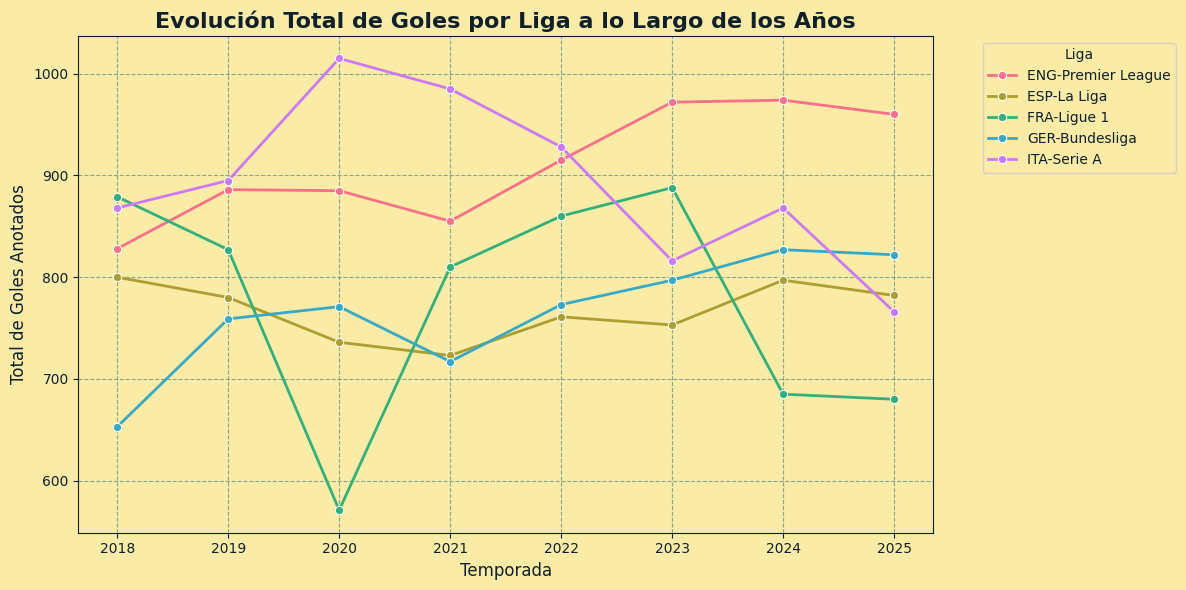

In [6]:
# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Crear el gráfico de líneas con Seaborn
sns.lineplot(
    data=goles_por_liga, 
    x='year',               # Eje X: El tiempo
    y='Performance_Gls',    # Eje Y: La suma de goles
    hue='league',           # Separa las líneas y colores por liga
    marker='o',             # Pone un puntito en cada año para mayor claridad
    linewidth=2             # Hace la línea un poco más gruesa
)

# Personalizar títulos y etiquetas
plt.title('Evolución Total de Goles por Liga a lo Largo de los Años', fontsize=16, fontweight='bold')
plt.xlabel('Temporada', fontsize=12)
plt.ylabel('Total de Goles Anotados', fontsize=12)

# Mover la leyenda afuera si estorba en la gráfica
plt.legend(title='Liga', bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir una cuadrícula para que sea más fácil leer los valores
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar el diseño para que no se corte nada
plt.tight_layout()

# Mostrar la gráfica
plt.show()

In [8]:
df_transfers.isna().sum()

player_id              0
transfer_date          0
transfer_season        0
from_club_name         0
to_club_name           0
transfer_fee           0
market_value_in_eur    0
year                   0
dtype: int64

In [7]:
# Agrupamos por año y calculamos el promedio del costo de transferencia
precio_promedio_por_ano = df_transfers.groupby('year')['transfer_fee'].mean().reset_index()

# Damos un vistazo rápido
display(precio_promedio_por_ano.head())

,year,transfer_fee
0,2017,3.155424e+06
1,2018,3.069621e+06
2,2019,3.389687e+06
3,2020,2.441614e+06
4,2021,1.890051e+06


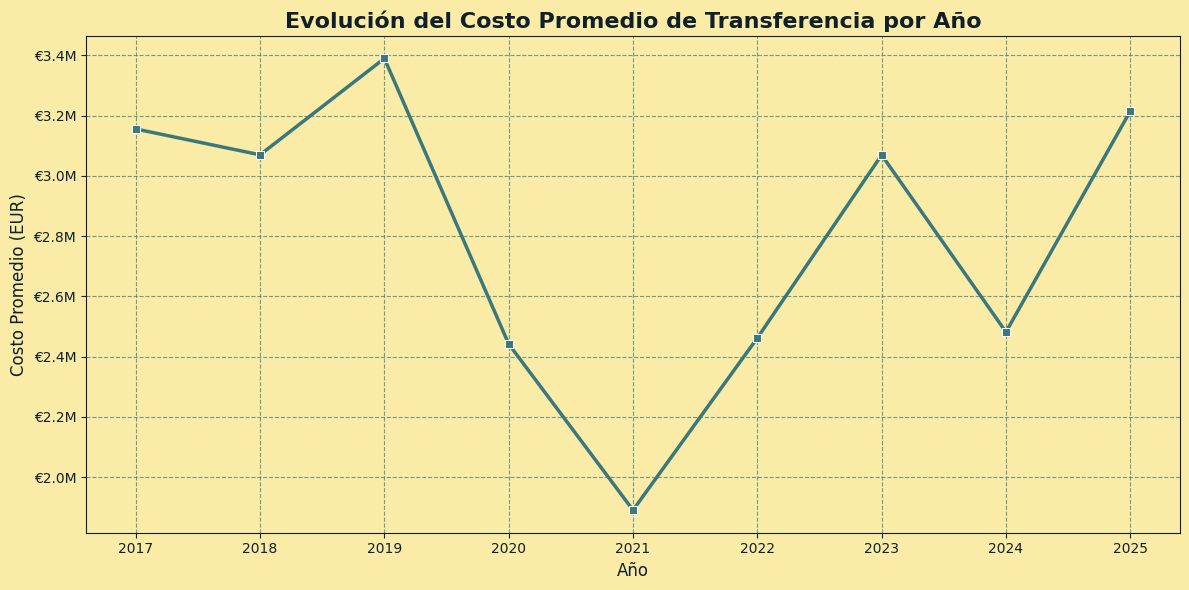

In [10]:
# Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# Crear el gráfico de líneas con Seaborn
sns.lineplot(
    data=precio_promedio_por_ano, 
    x='year',               # Eje X: El tiempo (Años)
    y='transfer_fee',       # Eje Y: Precio promedio
    marker='s',             # Marcador cuadrado ('s' de square) para los puntos
    linewidth=2.5           # Línea un poco más gruesa
)

# Personalizar títulos y etiquetas
plt.title('Evolución del Costo Promedio de Transferencia por Año', fontsize=16, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Costo Promedio (EUR)', fontsize=12)

# Opcional: Formatear el eje Y para que los números grandes (millones) sean más legibles
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'€{x/1e6:.1f}M'))

# Añadir una cuadrícula
plt.grid(True, linestyle='--', alpha=0.7)

# Ajustar el diseño
plt.tight_layout()

# Mostrar la gráfica
plt.show()